In [268]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [269]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


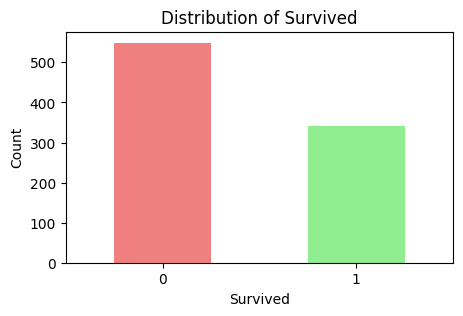

In [270]:
target_col = 'Survived'
plt.figure(figsize=(5,3))
df[target_col].value_counts().sort_index(ascending=True).plot(kind='bar', color=['lightcoral','lightgreen'])
plt.title(f"Distribution of {target_col}")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

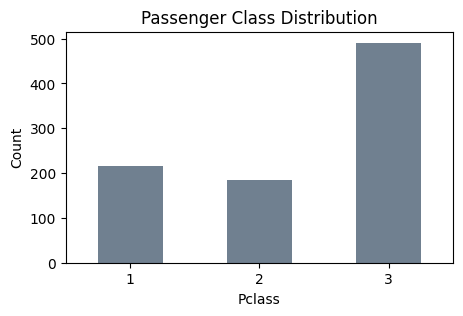

In [271]:
psngr_class_col = 'Pclass' if ('Pclass' in df.columns) else None
if psngr_class_col:
    plt.figure(figsize=(5,3))
    df[psngr_class_col].value_counts().sort_index(ascending=True).plot(kind='bar', color='slategrey')
    plt.title("Passenger Class Distribution")
    plt.xticks(rotation=0)
    plt.ylabel("Count")
    plt.show()

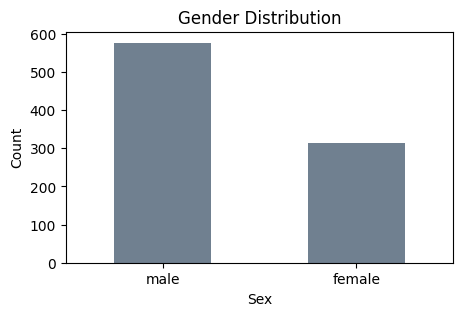

In [272]:
sex_col = 'Sex' if ('Sex' in df.columns) else None
if sex_col:
    plt.figure(figsize=(5,3))
    df[sex_col].value_counts().sort_index(ascending=False).plot(kind='bar', color='slategrey')
    plt.title("Gender Distribution")
    plt.xticks(rotation=0)
    plt.ylabel("Count")
    plt.show()

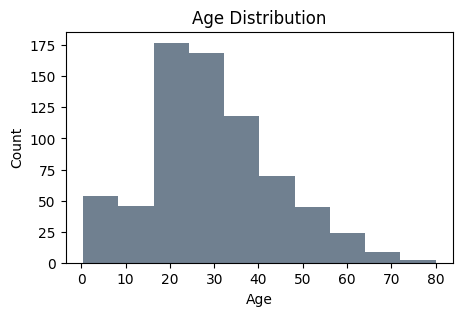

In [273]:
age_col = 'Age' if ('Age' in df.columns) else None
if age_col:
    plt.figure(figsize=(5,3))
    df[age_col].dropna().plot(kind='hist', color='slategrey')
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.xticks(rotation=0)
    plt.ylabel("Count")
    plt.show()

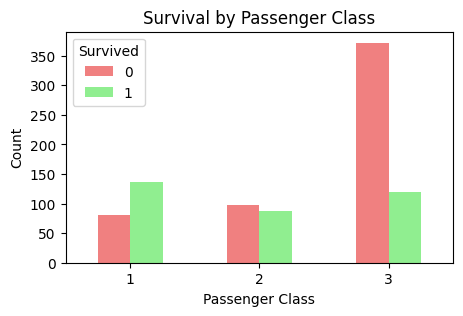

In [274]:
if target_col and psngr_class_col:
    pd.crosstab(df[psngr_class_col], df[target_col]).plot(kind='bar', figsize=(5,3), color=['lightcoral','lightgreen'])
    plt.title("Survival by Passenger Class")
    plt.xlabel("Passenger Class")
    plt.xticks(rotation=0)
    plt.ylabel("Count")
    plt.show()

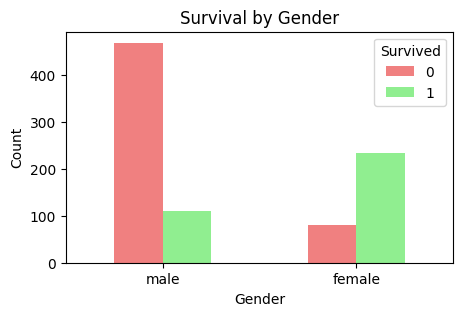

In [275]:
if target_col and sex_col:
    pd.crosstab(df[sex_col], df[target_col]).sort_index(ascending=False).plot(kind='bar', figsize=(5,3), color=['lightcoral','lightgreen'])
    plt.title('Survival by Gender')
    plt.xlabel("Gender")
    plt.xticks(rotation=0)
    plt.ylabel('Count')
    plt.show()

<Figure size 1000x600 with 0 Axes>

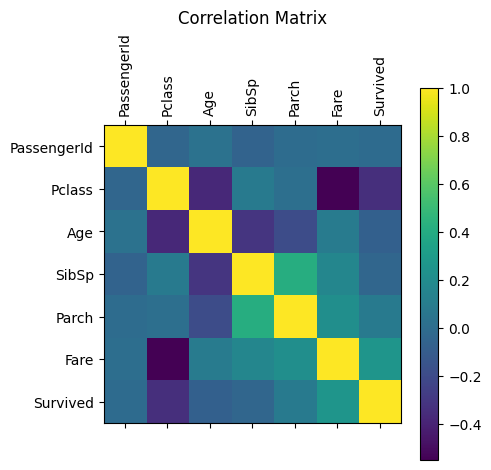

In [276]:
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr(numeric_only=True)
plt.matshow(correlation_matrix) # matrix like figure
plt.title("Correlation Matrix")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()


In [277]:
# Drop unnecessary columns
column_to_be_dropped = ['PassengerId','Name','Ticket','Cabin']
df = df.drop(columns=column_to_be_dropped, errors='ignore')
df.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Survived'],
      dtype='object')

In [278]:
target = df.columns[-1] # get survived column
y = df[target].astype(int)
X = df.iloc[:,:-1].copy() # get others column except servived
print(list(X.columns))
print(target)
X.head()

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Survived


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [293]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print('------------------')
print(X_train.head())
print('------------------')
print(X_test.head())
print('------------------')
print(y_train.head())
print('------------------')
print(y_test.head())

(668, 7) (223, 7)
------------------
     Pclass     Sex   Age  SibSp  Parch    Fare Embarked
486       1  female  35.0      1      0  90.000        S
238       2    male  19.0      0      0  10.500        S
722       2    male  34.0      0      0  13.000        S
184       3  female   4.0      0      2  22.025        S
56        2  female  21.0      0      0  10.500        S
------------------
     Pclass     Sex   Age  SibSp  Parch     Fare Embarked
157       3    male  30.0      0      0   8.0500        S
501       3  female  21.0      0      0   7.7500        Q
352       3    male  15.0      1      1   7.2292        C
82        3  female   NaN      0      0   7.7875        Q
683       3    male  14.0      5      2  46.9000        S
------------------
486    1
238    0
722    0
184    1
56     1
Name: Survived, dtype: int64
------------------
157    0
501    0
352    0
82     1
683    0
Name: Survived, dtype: int64


In [280]:
numerical_col = X_train.select_dtypes(include=np.number).columns.tolist()
category_col = X_train.select_dtypes(exclude=np.number).columns.tolist()
print(f"Numerical Col: {numerical_col}")
print(f"Categorical Col: {category_col}")

Numerical Col: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Col: ['Sex', 'Embarked']


In [281]:
# Numerical preprocessing to train and test sets
train = X_train.copy()
test = X_test.copy()

# replace negative values
for c in numerical_col:
    train.loc[train[c]<0,c]=np.nan
    test.loc[test[c]<0,c]=np.nan

# Fix missing values with medians
medians = {c: train[c].median() for c in numerical_col}
for c in numerical_col:
    train[c] = train[c].fillna(medians[c])
    test[c] = test[c].fillna(medians[c])



In [282]:
# IQR clip for outliers
q1 = train['Age'].quantile(0.25)
q3 = train['Age'].quantile(0.75)
iqr = q3-q1
lb = q1-1.5*iqr
ub = q3+1.5*iqr
print(q1,q3,iqr,lb,ub)

22.0 36.0 14.0 1.0 57.0


In [283]:
# IQR clip for outliers
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1-1.5*iqr, q3+1.5*iqr

for c in [x for x in ['Age','Fare'] if x in numerical_col]:
    lb, ub = iqr_bounds(train[c])
    train[c] = train[c].clip(lower = lb, upper = ub)
    test[c] = test[c].clip(lower = lb, upper = ub)


In [303]:
# Display descriptive statistics for numeric columns after preprocessing
print("\nDescription statistics for numerical columns (Train set)")
display(train[numerical_col].describe())


Description statistics for numerical columns (Train set)


,Pclass,Age,SibSp,Parch,Fare
count,668.000000,668.000000,668.000000,668.000000,668.000000
mean,2.312874,29.506737,0.464072,0.375749,23.441336
std,0.831906,12.309369,0.999353,0.832877,20.042501
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800
50%,3.000000,29.000000,0.000000,0.000000,13.860400
75%,3.000000,36.000000,1.000000,0.000000,30.500000
max,3.000000,57.000000,8.000000,6.000000,64.406300


In [302]:
# Display descriptive statistics for numeric columns after preprocessing
print("\nDescription statistics for numerical columns (Test set)")
display(test[numerical_col].describe())


Description statistics for numerical columns (Test set)


,Pclass,Age,SibSp,Parch,Fare
count,223.000000,223.000000,223.000000,223.000000,223.000000
mean,2.295964,28.744395,0.699552,0.399103,25.216374
std,0.850189,12.518442,1.353790,0.721235,20.478126
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,23.000000,0.000000,0.000000,8.050000
50%,3.000000,29.000000,0.000000,0.000000,15.850000
75%,3.000000,33.000000,1.000000,1.000000,35.500000
max,3.000000,57.000000,8.000000,4.000000,64.406300


In [286]:
print("\nTrain set after numeric preprocessing:")
display(train.head(10))

print("\nTest set after numeric preprocessing:")
display(test.head(10))


Train set after numeric preprocessing:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
486,1.0,female,35.0,1.0,0.0,64.4063,S
238,2.0,male,19.0,0.0,0.0,10.5000,S
722,2.0,male,34.0,0.0,0.0,13.0000,S
184,3.0,female,4.0,0.0,2.0,22.0250,S
56,2.0,female,21.0,0.0,0.0,10.5000,S
748,1.0,male,19.0,1.0,0.0,53.1000,S
638,3.0,female,41.0,0.0,5.0,39.6875,S
253,3.0,male,30.0,1.0,0.0,16.1000,S
140,3.0,female,29.0,0.0,2.0,15.2458,C
626,2.0,male,57.0,0.0,0.0,12.3500,Q



Test set after numeric preprocessing:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
157,3.0,male,30.0,0.0,0.0,8.0500,S
501,3.0,female,21.0,0.0,0.0,7.7500,Q
352,3.0,male,15.0,1.0,1.0,7.2292,C
82,3.0,female,29.0,0.0,0.0,7.7875,Q
683,3.0,male,14.0,5.0,2.0,46.9000,S
84,2.0,female,17.0,0.0,0.0,10.5000,S
779,1.0,female,43.0,0.0,1.0,64.4063,S
515,1.0,male,47.0,0.0,0.0,34.0208,S
728,2.0,male,25.0,1.0,0.0,26.0000,S
734,2.0,male,23.0,0.0,0.0,13.0000,S


In [292]:
# Replace nan values with the missing string
for c in category_col:
    train[c]=train[c].fillna('missing')
    test[c]=test[c].fillna('missing')

print(category_col)

['Sex', 'Embarked']


In [301]:
train_encoded_ohe = pd.get_dummies(train, columns=category_col, prefix=category_col, dtype=int)
test_encoded_ohe = pd.get_dummies(test, columns=category_col, prefix=category_col, dtype=int)

train_cols_ohe = train_encoded_ohe.columns
test_encoded_ohe = test_encoded_ohe.reindex(columns=train_cols_ohe, fill_value=0 )  # fix column mismatched issue using reindex()
display(train_encoded_ohe.head())
display(test_encoded_ohe.head())



,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_missing
486,1.0,35.0,1.0,0.0,64.4063,1,0,0,0,1,0
238,2.0,19.0,0.0,0.0,10.5000,0,1,0,0,1,0
722,2.0,34.0,0.0,0.0,13.0000,0,1,0,0,1,0
184,3.0,4.0,0.0,2.0,22.0250,1,0,0,0,1,0
56,2.0,21.0,0.0,0.0,10.5000,1,0,0,0,1,0


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_missing
157,3.0,30.0,0.0,0.0,8.0500,0,1,0,0,1,0
501,3.0,21.0,0.0,0.0,7.7500,1,0,0,1,0,0
352,3.0,15.0,1.0,1.0,7.2292,0,1,1,0,0,0
82,3.0,29.0,0.0,0.0,7.7875,1,0,0,1,0,0
683,3.0,14.0,5.0,2.0,46.9000,0,1,0,0,1,0
